In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
'''
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nimport os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

In [2]:
import os
import shutil
import random
from tqdm import tqdm

# 1. Klasör Yollarını Tanımlama
input_img_path = '/kaggle/input/turkish-license-plate-dataset/images'
# Etiketler hem images içinde hem label içinde olduğu için images içindekileri baz alacağız
output_base_dir = '/kaggle/working/license_plate_data'

# YOLO için gerekli alt klasörleri oluştur
sub_dirs = [
    'images/train', 'images/val',
    'labels/train', 'labels/val'
]

for sub_dir in sub_dirs:
    os.makedirs(os.path.join(output_base_dir, sub_dir), exist_ok=True)

# 2. Dosya Listelerini Hazırlama
# Sadece .jpg dosyalarını alalım (veya veri setindeki formata göre .png)
all_images = [f for f in os.listdir(input_img_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42) # Tekrarlanabilirlik için
random.shuffle(all_images)

# Split oranları (%90 train, %10 val)
split_idx = int(len(all_images) * 0.9)
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

def process_data(image_list, split_type):
    print(f"{split_type} verileri kopyalanıyor...")
    for img_name in tqdm(image_list):
        # Dosya isimleri (uzantısız)
        base_name = os.path.splitext(img_name)[0]
        
        # Kaynak yolları
        src_img = os.path.join(input_img_path, img_name)
        src_txt = os.path.join(input_img_path, base_name + '.txt')
        
        # Eğer etiket dosyası images içinde yoksa label klasörüne bak
        if not os.path.exists(src_txt):
            src_txt = os.path.join('/kaggle/input/turkish-license-plate-dataset/label', base_name + '.txt')

        # Hedef yolları
        dst_img = os.path.join(output_base_dir, 'images', split_type, img_name)
        dst_txt = os.path.join(output_base_dir, 'labels', split_type, base_name + '.txt')
        
        # Sadece hem görsel hem de etiket varsa kopyala (Veri bütünlüğü için kritik)
        if os.path.exists(src_img) and os.path.exists(src_txt):
            shutil.copy(src_img, dst_img)
            shutil.copy(src_txt, dst_txt)

# 3. İşlemi Başlat
process_data(train_images, 'train')
process_data(val_images, 'val')

print("\n✅ Veri seti YOLO formatına uygun şekilde hazırlandı!")
print(f"Konum: {output_base_dir}")

train verileri kopyalanıyor...


100%|██████████| 1759/1759 [01:27<00:00, 20.21it/s]


val verileri kopyalanıyor...


100%|██████████| 196/196 [00:08<00:00, 21.97it/s]


✅ Veri seti YOLO formatına uygun şekilde hazırlandı!
Konum: /kaggle/working/license_plate_data


In [3]:
yaml_content = f"""
path: {output_base_dir}
train: images/train
val: images/val

names:
  0: plaka
"""

with open('/kaggle/working/custom_data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ custom_data.yaml dosyası oluşturuldu.")

✅ custom_data.yaml dosyası oluşturuldu.


In [4]:
# YOLOv8 kütüphanesini güncelle/kur
!pip install -U ultralytics
import ultralytics
ultralytics.checks() # GPU ve sürüm kontrolü yapar

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6635.6/8062.4 GB disk)


In [5]:
from ultralytics import YOLO

# 'm' (medium) versiyonu; derinlik ve hız dengesi için en iyisidir.
model = YOLO('yolov8m.pt')

In [6]:
results = model.train(
    data='/kaggle/working/custom_data.yaml', # Hazırladığımız adres defteri
    epochs=60,                               # Toplam eğitim turu
    imgsz=640,                               # Giriş resim boyutu (CNN standardı)
    batch=16,                                # GPU belleğine göre ayarlandı
    name='plaka_tespit_modeli',              # Kayıt klasörü adı
    device=0,                                # GPU kullanımı
    
    # %98 F1 Skoru için Kritik Ayarlar:
    patience=15,    # Eğer 15 epoch boyunca skor gelişmezse eğitimi durdur (overfitting önleme)
    augment=True,   # Veri artırma (farklı ışık, açı vb.) otomatik uygula
    mosaic=1.0,     # 4 resmi birleştirip tek resim gibi göster (küçük nesneler -plakalar- için mükemmeldir)
    mixup=0.1,      # Resimleri üst üste bindirerek modelin kafasını karıştır ve daha iyi öğrenmesini sağla
    optimizer='AdamW' # ANN/CNN dünyasının en kararlı optimize edicilerinden biri
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/custom_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plaka_tespit_modeli, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15,

Test edilen resim: /kaggle/input/turkish-license-plate-dataset/images/1309.jpg

image 1/1 /kaggle/input/turkish-license-plate-dataset/images/1309.jpg: 384x640 1 plaka, 49.2ms
Speed: 2.4ms preprocess, 49.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


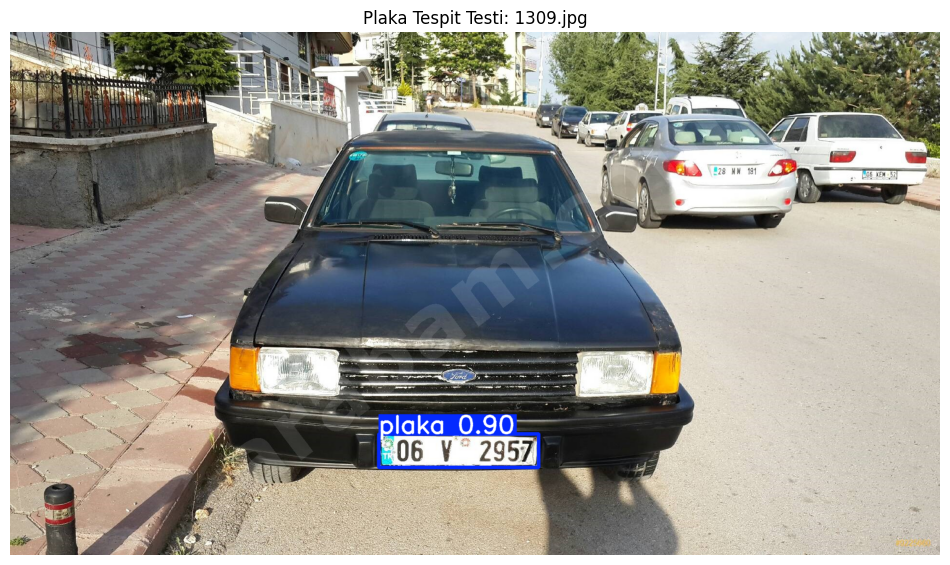

In [7]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Modeli yükle
model = YOLO('/kaggle/working/runs/detect/plaka_tespit_modeli/weights/best.pt')

# 2. Sadece resim dosyalarını filtreleyerek seç
test_path = '/kaggle/input/turkish-license-plate-dataset/images'
# Sadece jpg, jpeg veya png olanları listeye al
all_images = [f for f in os.listdir(test_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(all_images) > 0:
    random_img_name = random.choice(all_images) # Rastgele bir resim seç
    random_img_path = os.path.join(test_path, random_img_name)
    print(f"Test edilen resim: {random_img_path}")

    # 3. Tahmin yap
    results = model.predict(source=random_img_path, conf=0.45, save=False)

    # 4. Görselleştir
    res_plotted = results[0].plot()
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Plaka Tespit Testi: {random_img_name}")
    plt.axis('off')
    plt.show()
else:
    print("Klasörde uygun resim dosyası bulunamadı!")